In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ema_workbench.analysis import pairs_plotting
from ema_workbench.analysis import feature_scoring
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
from sklearn import tree
from pprint import pprint 
import graphviz
import sklearn
import dtreeviz

import os
import sys
sys.path.insert(0, '..')

from archspace import PipesAndFilters, ArchSpace
from archspace import show_pairplot, show_feature_scores, show_outcome_distributions, show_tradeoff_distribution
from archspace import show_quality_attribute_space2D, show_configuration_space2D

In [2]:
my_space = PipesAndFilters()
my_space.create_model('pipes_and_filters')

experiments_df, outcomes_df = my_space.load_results('./separated/Core1_N50.csv', kind='separated')
experiments_df, outcomes_df = my_space.load_results('./joint/Core1_N50.csv', kind='joint1')
experiments_df, outcomes_df = my_space.load_results('./joint/Core2_N50.csv', kind='joint2')

print(len(my_space.get_configurations()), "configurations")

(51, 53)
initial size: (51, 19)
(51, 45)
appended size: (51, 17)
final size: (102, 23)
(51, 45)
appended size: (51, 17)
final size: (153, 23)
3 configurations


In [3]:
experiments_df

,scenario,N_A,N_B,r_Z_A,r_Z_B,c_A_T1,c_A_T2,c_A_T3,c_B_T1,c_B_T2,...,r_A_T3,r_B_T1,r_B_T2,r_B_T4,policy,model,c_T1,c_T2,c_T3,c_T4
0,0,0,50,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
1,26,1,49,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
2,14,2,48,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
3,24,3,47,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
4,8,4,46,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,44,46,4,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.090909,0.125,0.111111,0.1,joint2,pipes_and_filters,2.0,2.0,1.0,1.0
149,49,47,3,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.090909,0.125,0.111111,0.1,joint2,pipes_and_filters,2.0,2.0,1.0,1.0
150,48,48,2,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.090909,0.125,0.111111,0.1,joint2,pipes_and_filters,2.0,2.0,1.0,1.0
151,50,49,1,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.090909,0.125,0.111111,0.1,joint2,pipes_and_filters,2.0,2.0,1.0,1.0


In [4]:
experiments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   scenario  153 non-null    int64  
 1   N_A       153 non-null    int64  
 2   N_B       153 non-null    int64  
 3   r_Z_A     153 non-null    float64
 4   r_Z_B     153 non-null    float64
 5   c_A_T1    153 non-null    float64
 6   c_A_T2    153 non-null    float64
 7   c_A_T3    153 non-null    float64
 8   c_B_T1    153 non-null    float64
 9   c_B_T2    153 non-null    float64
 10  c_B_T4    153 non-null    float64
 11  r_A_T1    153 non-null    float64
 12  r_A_T2    153 non-null    float64
 13  r_A_T3    153 non-null    float64
 14  r_B_T1    153 non-null    float64
 15  r_B_T2    153 non-null    float64
 16  r_B_T4    153 non-null    float64
 17  policy    153 non-null    object 
 18  model     153 non-null    object 
 19  c_T1      153 non-null    float64
 20  c_T2      153 non-null    float6

In [5]:
set(experiments_df['policy'])

{'joint1', 'joint2', 'separated'}

/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
OMP: Info #270: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


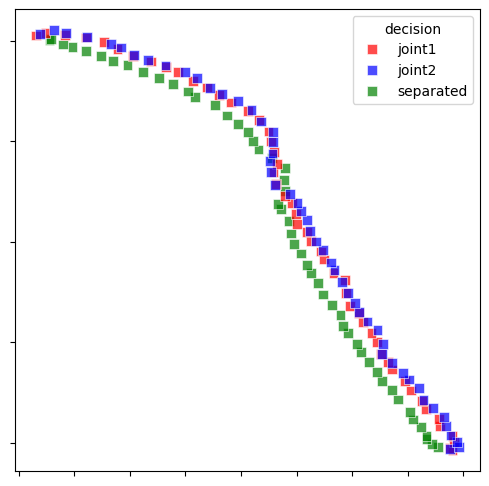

In [6]:
color_key = {'joint1': 'red',
             'joint2': 'blue',
             'separated': 'green'}
embeddings_df = show_configuration_space2D(experiments_df, color_key=color_key, alpha=0.7)

In [7]:
outcomes_df

,response_time,throughput
0,499.249210,0.099791
1,463.084476,0.107218
2,442.670668,0.113486
3,418.936206,0.119132
4,394.396731,0.126913
...,...,...
148,423.371992,0.117835
149,449.393022,0.111153
150,477.677100,0.104256
151,513.253163,0.097508


In [8]:
outcomes_df.describe()

,response_time,throughput
count,153.000000,153.000000
mean,437.472641,0.124346
std,133.945059,0.033946
min,292.663578,0.066709
25%,316.155208,0.094044
50%,394.396731,0.127034
75%,530.775707,0.157636
max,749.529749,0.171054


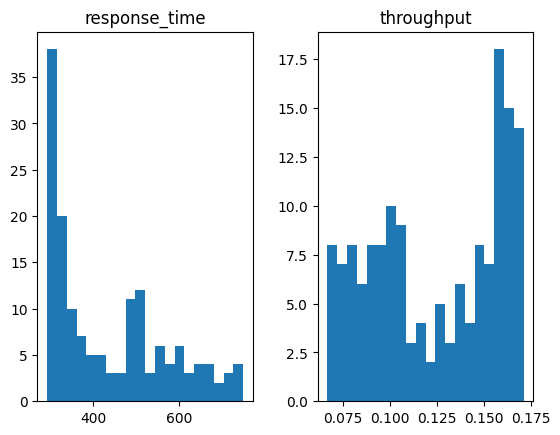

In [9]:
# outcomes
outcomes_df.hist(bins=20, grid=False)
plt.show()

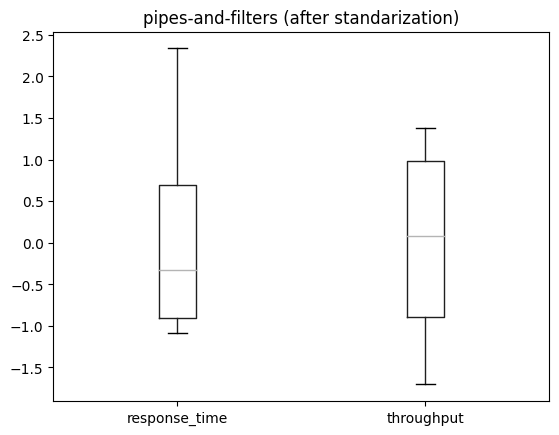

In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outcomes_df)
scaled_df = pd.DataFrame(scaled_data, columns=outcomes_df.columns)
scaled_df.boxplot(grid=False)
plt.title('pipes-and-filters (after standarization)')
plt.show()

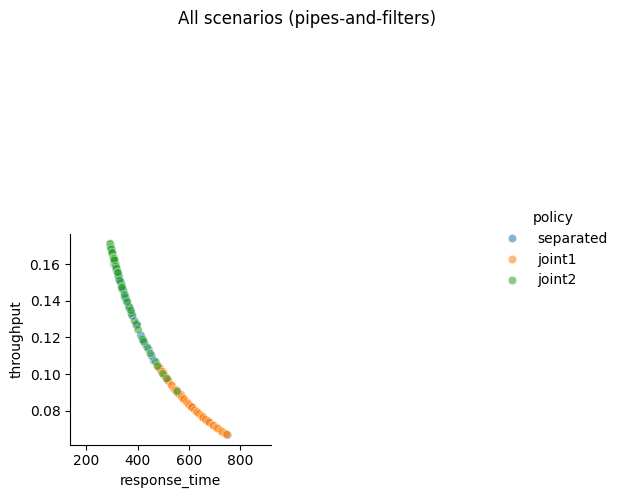

In [11]:
#show_pairplot(my_space, title='All scenarios (gateway offloading)', kind='sns')
show_pairplot(my_space, title='All scenarios (pipes-and-filters)', kind='sns', group='policy', legend=True) #, filename=None)

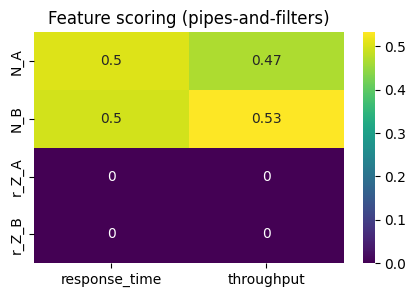

,response_time,throughput
0,,
N_A,0.504303,0.467433
N_B,0.495697,0.532567
r_Z_A,0.000000,0.000000
r_Z_B,0.000000,0.000000


In [12]:
policy_size = (5,3)
filter_params = PipesAndFilters.COMMON_PARAMETERS
fs = show_feature_scores(my_space, title='Feature scoring (pipes-and-filters)', parameters=filter_params, size=policy_size) #, filename=None)  
fs

In [13]:
my_policies = my_space.get_configurations()
my_policies

['joint2', 'separated', 'joint1']

Instances for configuration: (51, 14)


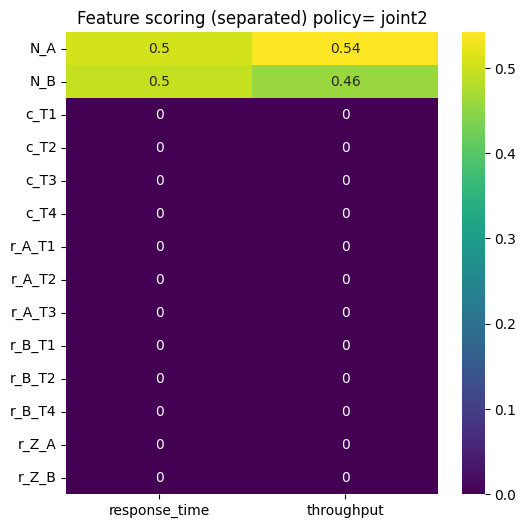

,response_time,throughput
0,,
N_A,0.504665,0.541957
N_B,0.495335,0.458043
c_T1,0.000000,0.000000
c_T2,0.000000,0.000000
c_T3,0.000000,0.000000
c_T4,0.000000,0.000000
r_A_T1,0.000000,0.000000
r_A_T2,0.000000,0.000000
r_A_T3,0.000000,0.000000


In [14]:
show_feature_scores(my_space, title='Feature scoring (separated)', policy=my_policies[0]) #, filename=None)

Instances for configuration: (51, 16)


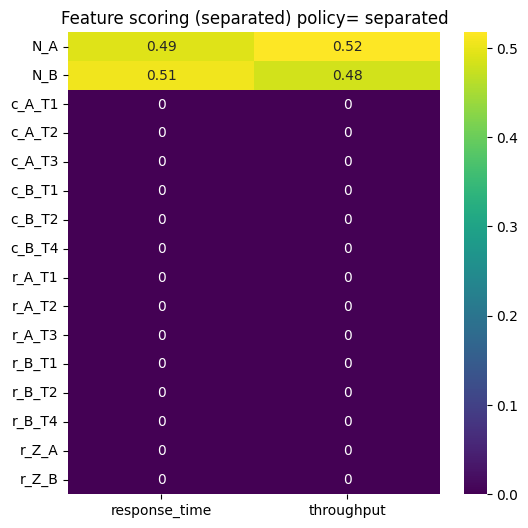

,response_time,throughput
0,,
N_A,0.493024,0.517851
N_B,0.506976,0.482149
c_A_T1,0.000000,0.000000
c_A_T2,0.000000,0.000000
c_A_T3,0.000000,0.000000
c_B_T1,0.000000,0.000000
c_B_T2,0.000000,0.000000
c_B_T4,0.000000,0.000000
r_A_T1,0.000000,0.000000


In [15]:
show_feature_scores(my_space, title='Feature scoring (separated)', policy=my_policies[1]) #, filename=None)

Instances for configuration: (51, 14)


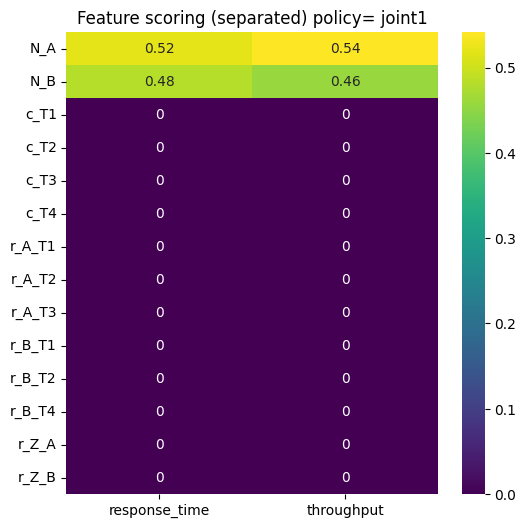

,response_time,throughput
0,,
N_A,0.519755,0.54148
N_B,0.480245,0.45852
c_T1,0.000000,0.00000
c_T2,0.000000,0.00000
c_T3,0.000000,0.00000
c_T4,0.000000,0.00000
r_A_T1,0.000000,0.00000
r_A_T2,0.000000,0.00000
r_A_T3,0.000000,0.00000


In [16]:
show_feature_scores(my_space, title='Feature scoring (separated)', policy=my_policies[2]) #, filename=None)

Absolute ranges: [(292.0, 750.0), (0.0, 0.25)]
response_time [291.9, 444.6333333333333, 597.3666666666667, 750.1]
throughput [-0.1, 0.04999999999999999, 0.19999999999999998, 0.35]


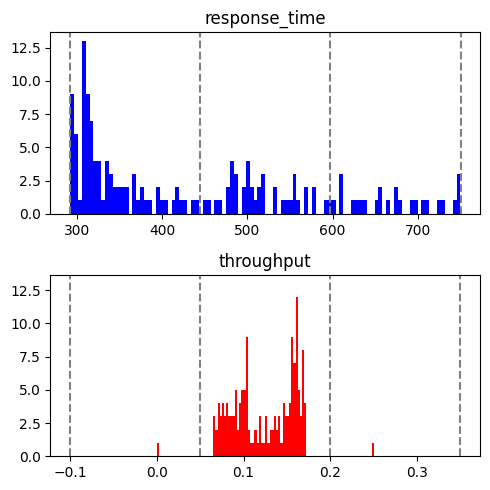

{'response_time': [291.9, 444.6333333333333, 597.3666666666667, 750.1],
 'throughput': [-0.1, 0.04999999999999999, 0.19999999999999998, 0.35]}

In [17]:
MIN_RESPONSE_TIME, MAX_RESPONSE_TIME = (292.0, 750.0)
MIN_THROUGHPUT,  MAX_THROUGHPUT = (0.0, 0.25)

MIN_MAX_RANGES = [(MIN_RESPONSE_TIME, MAX_RESPONSE_TIME), (MIN_THROUGHPUT, MAX_THROUGHPUT)]
print('Absolute ranges:', MIN_MAX_RANGES)

show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5))

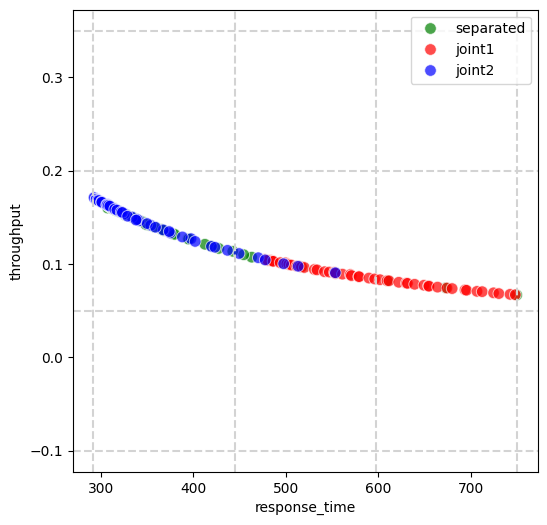

In [18]:
df = outcomes_df.copy()
df['decision'] = experiments_df['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7,color_key=color_key, qualities=['response_time', 'throughput'])

In [19]:
print("Configurations:", my_space.get_configurations())

Configurations: ['joint2', 'separated', 'joint1']


Experiments for policy separated : 51
response_time [291.9, 444.6333333333333, 597.3666666666667, 750.1]
throughput [-0.1, 0.04999999999999999, 0.19999999999999998, 0.35]


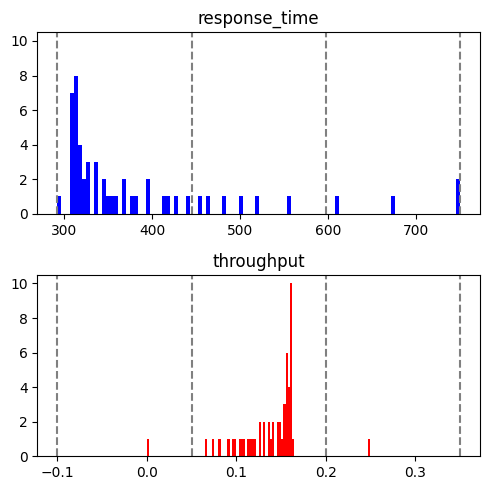

{'response_time': [291.9, 444.6333333333333, 597.3666666666667, 750.1],
 'throughput': [-0.1, 0.04999999999999999, 0.19999999999999998, 0.35]}

In [20]:
show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5), policy='separated')

In [21]:
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", experiments_df.shape)

config = "separated"
exp_df, out_df, discrete_out_df = my_space.get_experiment(config)

# print(exp_df.head())
# print(out_df.head())
# print(discrete_exp_df)
print(my_space.available_tradeoffs_)
print("Tradeoffs for ", config,"-->", PipesAndFilters.get_tradeoffs(discrete_out_df))
discrete_out_df.head(10)

Experiments: (153, 23)
Counter({'fast,average': 87, 'average,average': 42, 'slow,average': 24})
Tradeoffs for  separated --> Counter({'fast,average': 42, 'average,average': 6, 'slow,average': 3})


,response_time,throughput
0,average,average
1,average,average
2,fast,average
3,fast,average
4,fast,average
5,fast,average
6,fast,average
7,fast,average
8,fast,average
9,fast,average


In [22]:
my_space.available_tradeoffs_

Counter({'fast,average': 87, 'average,average': 42, 'slow,average': 24})

In [23]:
X_train, X_test, y_train, y_test = my_space.split_dataset(test_size=0.2)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(153, 25) 153
Instances to remove (not enough tradeoffs): set()
{'average,average', 'fast,average', 'slow,average'}
(153, 25) 153
(122, 25) (122, 2) (31, 25) (31, 2)


In [24]:
X_train

,scenario,N_A,N_B,r_Z_A,r_Z_B,c_A_T1,c_A_T2,c_A_T3,c_B_T1,c_B_T2,...,r_B_T2,r_B_T4,policy,model,c_T1,c_T2,c_T3,c_T4,response_time,throughput
0,11,15,35,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.111111,0.1,joint2,pipes_and_filters,2.0,2.0,1.0,1.0,302.399001,0.165185
1,35,36,14,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.111111,0.1,joint2,pipes_and_filters,2.0,2.0,1.0,1.0,321.968317,0.155537
2,47,3,47,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.111111,0.1,joint1,pipes_and_filters,1.0,1.0,1.0,1.0,483.366712,0.103573
3,1,18,32,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.111111,0.1,joint1,pipes_and_filters,1.0,1.0,1.0,1.0,533.685311,0.093608
4,25,30,20,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.111111,0.1,joint1,pipes_and_filters,1.0,1.0,1.0,1.0,601.732015,0.083048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,14,11,39,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.111111,0.1,joint1,pipes_and_filters,1.0,1.0,1.0,1.0,503.216356,0.099356
118,4,8,42,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.111111,0.1,joint2,pipes_and_filters,2.0,2.0,1.0,1.0,341.502978,0.146219
119,18,26,24,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.111111,0.1,joint1,pipes_and_filters,1.0,1.0,1.0,1.0,578.761530,0.086356
120,27,23,27,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0,308.024437,0.162471


In [25]:
my_space.import_dataset(X_train, y_train)

In [26]:
# reference_tradeoff = 'average,low'
# # reference_tradeoff = ['fast,low', 'fast,average']
# r1, qat = my_space.compute_robustness([config], reference_tradeoff)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# print()

# list_of_configs = my_space.get_nearest_configurations(config, k=1)
# # list_of_configs = configs_df.values.tolist()
# # print(all(isinstance(elem, list) for elem in list_of_configs), list_of_configs)
# r1, qat = my_space.compute_robustness(list_of_configs, reference_tradeoff) 
# print("Robustness of list of solutions", list_of_configs, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# # print(configs_df)
# print()
# qa_config = 'fast,low' 
# qa_configs = my_space.get_nearest_tradeoffs(qa_config, k=1)
# print("Neighbors of:", qa_configs)
# print()
# qat = my_space.get_nearest_tradeoffs(qa_config, k=2)
# r1, qat = my_space.compute_robustness([config], qa_config)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# r1, qat = my_space.compute_robustness([config], qa_configs[0:2])
# print("Robustness of single solution", config, "w.r.t list of tradeoffs:", qat, "-->", round(r1*100, 2), "%")
# print()

Computing robustness for all configurations...


100%|██████████| 3/3 [00:00<00:00, 18.88it/s]


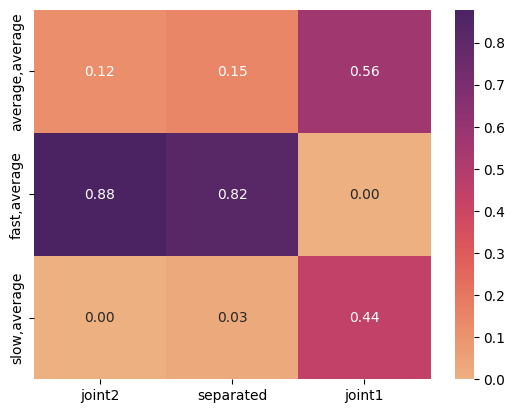

,joint2,separated,joint1
"average,average",0.121951,0.150,0.560976
"fast,average",0.878049,0.825,0.000000
"slow,average",0.000000,0.025,0.439024


In [27]:
print("Computing robustness for all configurations...")
df = my_space.compute_robustness_matrix()
# df.to_csv('./pipesandfilters_robustness_matrix.csv')

sns.heatmap(df, annot=True, fmt=".2f", cmap='flare')
plt.show()
df

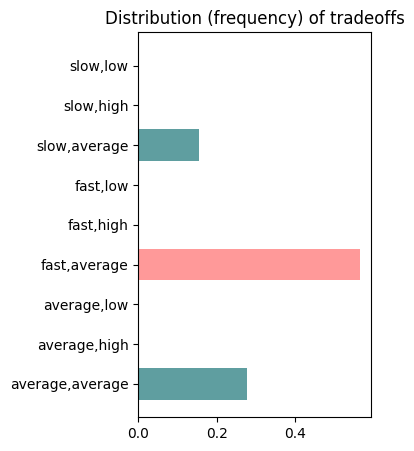

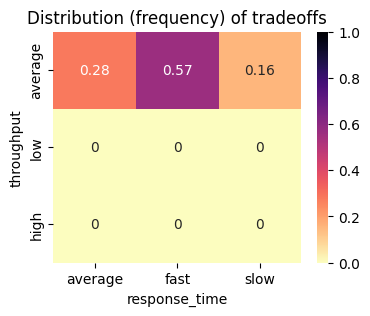

In [28]:
show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

separated Counter({'fast,average': 33, 'average,average': 6, 'slow,average': 1})
Instances for configuration: (40, 2)


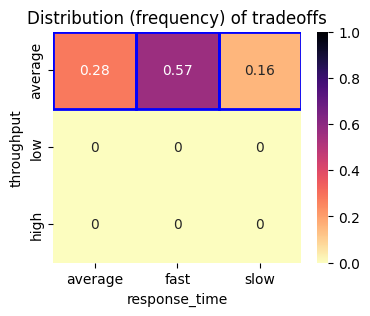

In [29]:
config = 'separated'
# show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [30]:
_, _, config_outcomes_df = my_space.get_experiment(config)
# config_outcomes_df

joint1 Counter({'average,average': 23, 'slow,average': 18})
Instances for configuration: (41, 2)


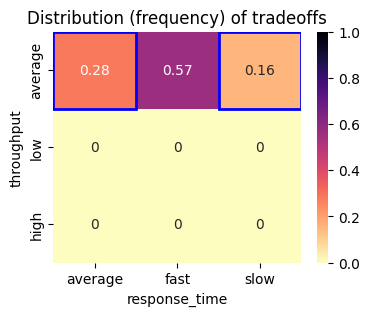

In [31]:
config = 'joint1'
# show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [32]:
_, _, config_outcomes_df = my_space.get_experiment(config)
# config_outcomes_df

joint2 Counter({'fast,average': 36, 'average,average': 5})
Instances for configuration: (41, 2)


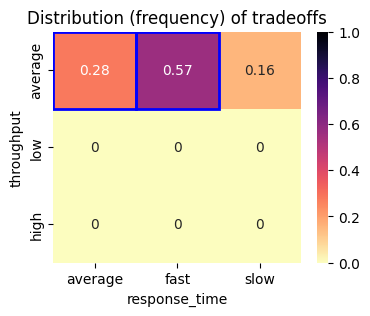

In [33]:
config = 'joint2'
# show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [34]:
_, _, config_outcomes_df = my_space.get_experiment(config)
# config_outcomes_df

In [35]:
label_values_df = my_space.describe_labels(n_bins=3)
label_values_df

,objective,min,max,label
0,response_time,292.563578,444.393038,fast
1,response_time,444.393038,596.222498,average
2,response_time,596.222498,748.051959,slow
3,throughput,-0.033044,0.068322,low
4,throughput,0.068322,0.169688,average
5,throughput,0.169688,0.271054,high


In [40]:
kp = ['N_A', 'N_B']
rules, cart_model = my_space.run_cart(key_parameters=kp, prune_tree=True)
clf = cart_model.clf
print("nodes:", clf.tree_.node_count, "leaves:", clf.get_n_leaves())

for r in rules:
    print(r)

# cart_model.stats_to_dataframe()
# cart_model.boxes_to_dataframe()

(122, 2) Index(['N_A', 'N_B'], dtype='object')
Running CART ...
nodes: 29 leaves: 25
if N_B > 20.5 and N_B <= 46.5 then class: fast,average (proba: 68.0%) | based on 63 samples
if N_B <= 20.5 and N_A <= 43.5 then class: fast,average (proba: 66.0%) | based on 32 samples
if N_B > 20.5 and N_B > 46.5 then class: fast,average (proba: 78.0%) | based on 9 samples
if N_B <= 20.5 and N_A > 43.5 and N_B > 3.5 then class: fast,average (proba: 33.0%) | based on 9 samples
if N_B <= 20.5 and N_A > 43.5 and N_B <= 3.5 then class: average,average (proba: 56.00000000000001%) | based on 9 samples


|--- feature_1 <= 20.50
|   |--- feature_0 <= 43.50
|   |   |--- class: 0
|   |--- feature_0 >  43.50
|   |   |--- feature_1 <= 3.50
|   |   |   |--- class: 2
|   |   |--- feature_1 >  3.50
|   |   |   |--- class: 0
|--- feature_1 >  20.50
|   |--- feature_1 <= 46.50
|   |   |--- class: 0
|   |--- feature_1 >  46.50
|   |   |--- class: 1



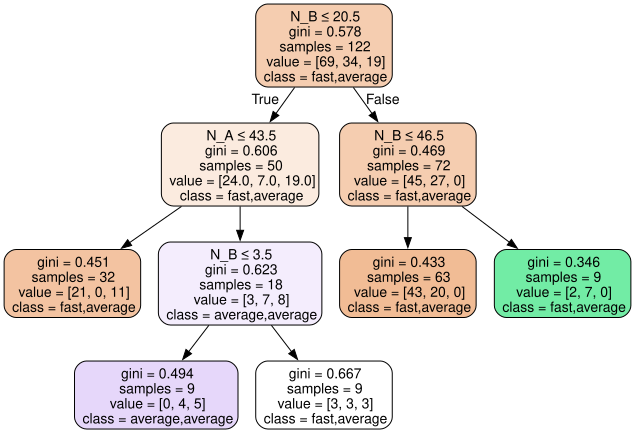

In [41]:
class_names =  my_space._get_cluster_labels()
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=kp, class_names=class_names,
                                filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)

print(tree.export_text(cart_model.clf))
# pprint(tree.export_text(prunedTree))

graph

In [36]:
# my_space.import_dataset(X_test, y_test)
my_space.import_dataset(X_train, y_train)
print("  Computing robustness for all configurations...")
print(my_space.available_tradeoffs_)

df = my_space.compute_robustness_matrix()
df

  Computing robustness for all configurations...
Counter({'fast,average': 69, 'average,average': 34, 'slow,average': 19})


100%|██████████| 3/3 [00:00<00:00, 32.57it/s]

separated
joint1
joint2


,separated,joint1,joint2
"average,average",0.150,0.560976,0.121951
"fast,average",0.825,0.000000,0.878049
"slow,average",0.025,0.439024,0.000000


In [37]:
warnings.filterwarnings('ignore')
my_space.import_dataset(X_train, y_train)

kp = ['N_A', 'N_B']

for qa_label in my_space.available_tradeoffs_.keys():
    my_space.import_dataset(X_train, y_train)
    n = my_space.available_tradeoffs_[qa_label]
    
    if n > 0:
        print("Checking (with PRIM) ----")
        property_to_check = my_space.get_property_box(qa_label)
        print("  ", qa_label, property_to_check)
        
        box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp, verbose=False)
        print("  New ranges:",  prange)

        my_space.import_dataset(X_test, y_test)
        my_space.adjust_parameters(prange)
        _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
        print("  Experiments:", my_space.experiments_df_.shape)

        print("  Computing robustness for all configurations...")
        df = my_space.compute_robustness_matrix()
        print(df)
        # plt.show()

Checking (with PRIM) ----
   fast,average {'response_time': (291.9, 444.6333333333333), 'throughput': (0.04999999999999999, 0.19999999999999998)}
  New ranges: {'N_A': {'min': 12.0, 'max': 43.0}, 'N_B': {'min': 9.0, 'max': 39.0}}
  Experiments: (16, 23)
  Computing robustness for all configurations...


100%|██████████| 3/3 [00:00<00:00, 31.64it/s]

separated
joint1
joint2
                 separated    joint1  joint2
average,average        0.0  0.571429     0.0
fast,average           1.0  0.000000     1.0
slow,average           0.0  0.428571     0.0
Checking (with PRIM) ----
   average,average {'response_time': (444.6333333333333, 597.3666666666667), 'throughput': (0.04999999999999999, 0.19999999999999998)}
  New ranges: {}
  Experiments: (31, 23)
  Computing robustness for all configurations...



  0%|          | 0/3 [00:00<?, ?it/s]

separated
joint1

100%|██████████| 3/3 [00:00<00:00, 40.22it/s]



joint2
                 separated  joint1  joint2
average,average   0.000000     0.7     0.1
fast,average      0.818182     0.0     0.9
slow,average      0.181818     0.3     0.0
Checking (with PRIM) ----
   slow,average {'response_time': (597.3666666666667, 750.1), 'throughput': (0.04999999999999999, 0.19999999999999998)}
  New ranges: {'N_B': {'min': 0.0, 'max': 18.0}}
  Experiments: (11, 23)
  Computing robustness for all configurations...


100%|██████████| 3/3 [00:00<00:00, 61.36it/s]

separated
joint1
joint2
                 separated  joint1  joint2
average,average        0.0     0.0    0.25
fast,average           0.6     0.0    0.75
slow,average           0.4     1.0    0.00


In [38]:
my_space.import_dataset(X_train, y_train)

# PipesAndFilters.get_property_box('fast,average', label_values_df)
qa_label = 'average,average' #'fast,average' 
property_to_check = my_space.get_property_box(qa_label)
print(qa_label, property_to_check)

average,average {'response_time': (444.6333333333333, 597.3666666666667), 'throughput': (0.04999999999999999, 0.19999999999999998)}


In [39]:
# my_space.experiments_df_.columns

In [40]:
# kp = ['N_A', 'N_B']
target_policy = 'joint1' 
box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='emaw', key_parameters=kp, policy=target_policy)
# box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp)
prange

Instances satisfying property: True     23
False    18
Name: count, dtype: int64
Total instances: (41, 2)
Running PRIM ... emaw
1 boxes


{'N_A': {'min': 0.0, 'max': 30.0}, 'N_B': {'min': 21.0, 'max': 50.0}}

[<Figure size 640x480 with 1 Axes>]

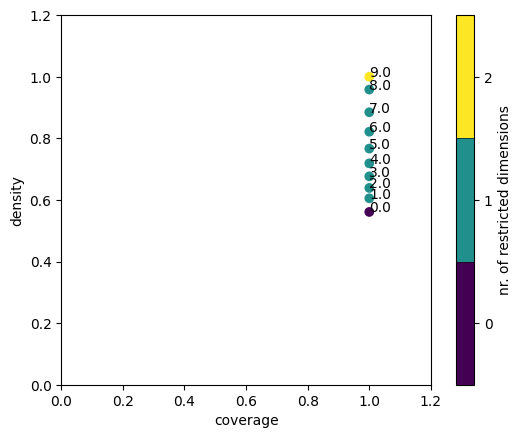

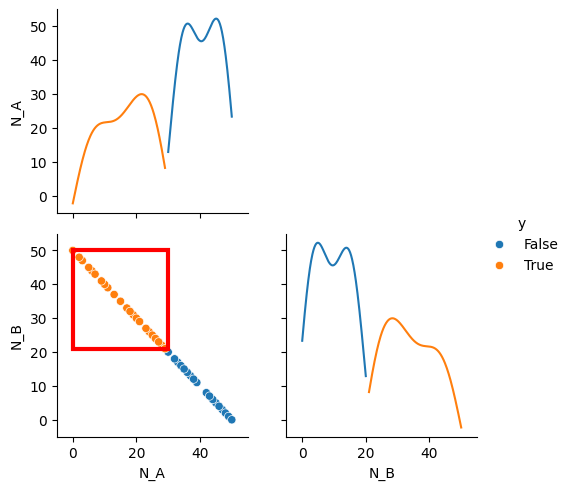

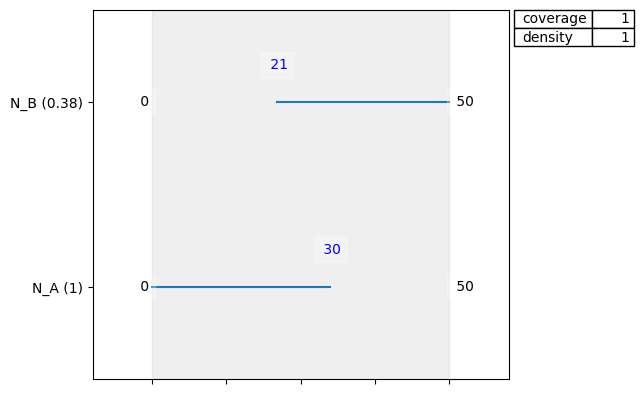

In [41]:
# EMAWorkbench
# fig = plt.figure(figsize=(24,12))
box1.show_tradeoff(annotated=True)
box1.show_pairs_scatter(upper='none', lower='scatter')
box1.inspect(style='graph')

In [42]:
my_space.import_dataset(X_test, y_test)

In [43]:
my_space.experiments_df_

,scenario,N_A,N_B,r_Z_A,r_Z_B,c_A_T1,c_A_T2,c_A_T3,c_B_T1,c_B_T2,...,r_A_T3,r_B_T1,r_B_T2,r_B_T4,policy,model,c_T1,c_T2,c_T3,c_T4
0,15,22,28,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.090909,0.125,0.111111,0.1,joint1,pipes_and_filters,1.0,1.0,1.0,1.0
1,10,15,35,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
2,32,31,19,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.090909,0.125,0.111111,0.1,joint1,pipes_and_filters,1.0,1.0,1.0,1.0
3,37,40,10,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
4,37,1,49,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.090909,0.125,0.111111,0.1,joint1,pipes_and_filters,1.0,1.0,1.0,1.0
5,36,36,14,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
6,24,3,47,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
7,44,48,2,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.090909,0.125,0.111111,0.1,separated,pipes_and_filters,0.0,0.0,0.0,0.0
8,13,9,41,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.090909,0.125,0.111111,0.1,joint2,pipes_and_filters,2.0,2.0,1.0,1.0
9,4,16,34,0.01,0.01,0.0,0.0,0.0,0.0,0.0,...,0.090909,0.125,0.111111,0.1,joint1,pipes_and_filters,1.0,1.0,1.0,1.0


Reducing range for tradeoff: average,average {'response_time': (444.6333333333333, 597.3666666666667), 'throughput': (0.04999999999999999, 0.19999999999999998)}
New ranges: {'N_A': {'min': 0.0, 'max': 30.0}, 'N_B': {'min': 21.0, 'max': 50.0}}
Experiments: (18, 23)


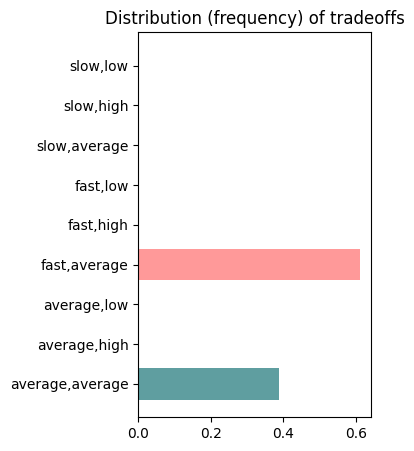

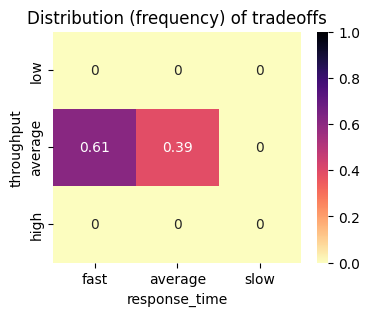

In [44]:
print("Reducing range for tradeoff:", qa_label, property_to_check)
print("New ranges:",  prange)

my_space.adjust_parameters(prange)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

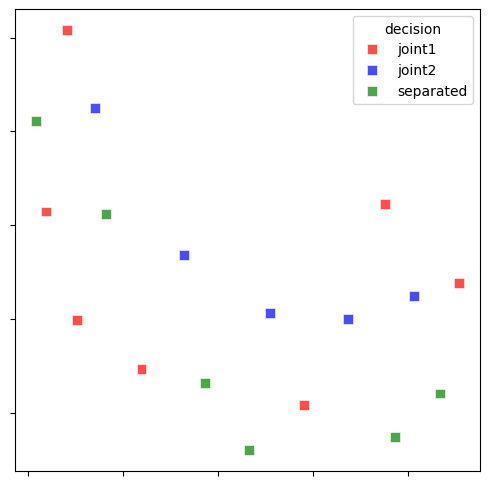

In [45]:
embeddings_df = show_configuration_space2D(my_space.experiments_df_, color_key=color_key, alpha=0.7)

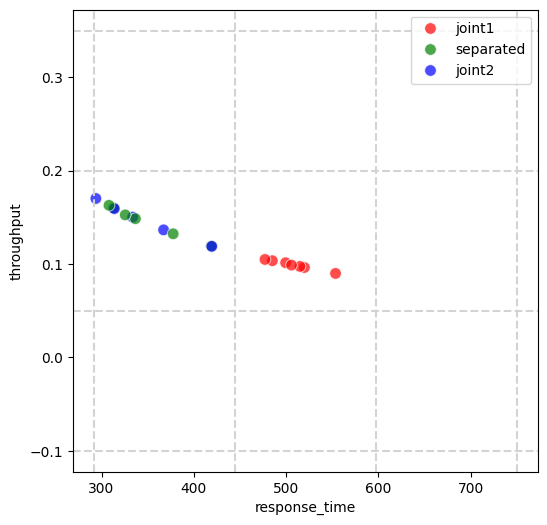

In [46]:
df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7, color_key=color_key, qualities=['response_time', 'throughput'])

In [47]:
print("Computing robustness for all configurations...")
main_dict = dict()
for exp in tqdm(my_space.get_configurations()):
    print(exp)
    main_dict[str(exp)] = dict()
    for qa in my_space.available_tradeoffs_.keys():
        main_dict[str(exp)][qa], _ = my_space.compute_robustness(exp, qa)
df = pd.DataFrame.from_dict(main_dict, orient='columns').sort_index()
df

Computing robustness for all configurations...


100%|██████████| 3/3 [00:00<00:00, 71.72it/s]

separated
joint1
joint2


,separated,joint1,joint2
"average,average",0.0,1.0,0.0
"fast,average",1.0,0.0,1.0
